In [29]:
from model_complex import InfluenzaData
from prediction_module.predictor import PredictionGenerator
%load_ext autoreload
%autoreload 2

Failed to reload module 'cutils_ext' from file 'C:\Users\105\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26200-SP0-AMD64_Family_25_Model_117_Stepping_2_AuthenticAMD-3.12.7-64\cutils_ext\__init__.py'
Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


In [3]:
city = 'russia'
save_path_folder='report_rscf/'
epid_data = InfluenzaData(city, begin_year=2025, begin_week=35, end_year=2026, end_week=21)

predictor = PredictionGenerator(epid_data=epid_data,
                                city=city,
                                save_path=save_path_folder)
predictor

https://db.influenza.spb.ru/scripts/report/rmancgi.exe?reportname=get_csv&id=aripcr&byear=2025&bweek=35&eyear=2026&eweek=21&district=0&auth=7e283896cf78e49c321dc60fab2850745a25215b621f600f648424d242a78c4a


In [16]:
coef_array_data = np.array(10000 / epid_data.returned_df["total_population"])
coef_array_data

array([0.00018175, 0.00018175, 0.00018175, 0.00018175, 0.00018174,
       0.00018177, 0.00018177, 0.00018177, 0.00018177, 0.00018177,
       0.00018177, 0.00018177, 0.00018177, 0.00018177, 0.00018177,
       0.00018177, 0.00018177, 0.00018177, 0.00018177, 0.00018177,
       0.00018157, 0.00018157, 0.00018157, 0.00018157, 0.00018157,
       0.00018157, 0.00018157, 0.00018157, 0.00018157, 0.00018156,
       0.00018156, 0.00018156, 0.00018156, 0.00018156, 0.00018156,
       0.00018156, 0.00018156, 0.00018156, 0.00018156])

In [7]:
from plot_module.calibration.calibration_and_forecast import calculate_coefficients, prepare_calibration_data,get_model_and_function
coef_array_data, coef_array_forecast, coef_array_all = calculate_coefficients(epid_data, 4)
model, model_params, func_to_get_newly_data = get_model_and_function(epid_data, type)
data, dur, plot_data = prepare_calibration_data(epid_data, type)


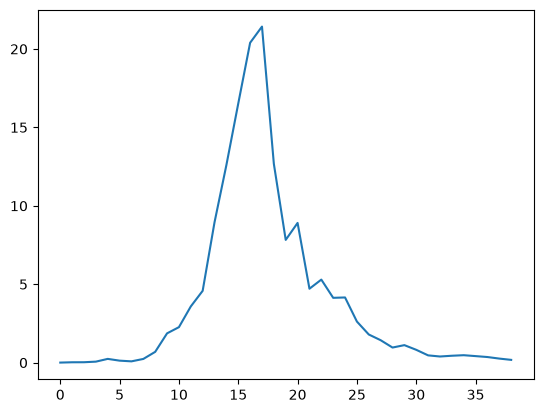

In [17]:

import matplotlib.pyplot as plt
plt.plot(plot_data[:, 0] * coef_array_data)

In [24]:
"""
Decisive diagnostic for a 2-parameter epidemic blackbox:
brute-force grid scan over the FULL prior box to answer:
  (A) Does ANY (alpha, beta) reproduce the observed wave?
  (B) If yes: where is the good region, and what epsilon should be?
  (C) If no: the model is structurally wrong - fix the model, not the sampler.

Plug your simulator into run_model() and your data into Y_OBS, then: python grid_scan.py
"""
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from model_complex.models import Model
from model_complex.utils import ModelParams

simulate_params = ModelParams(
            alpha=[0],
            beta=[0],
            population_size=model_params.population_size,
            initial_infectious=model_params.initial_infectious,
        )
time_step='week'
alpha_dim, beta_dim = model.params()
duration = len(data) // alpha_dim
get_newly_infected_base_on_time_step = model.get_daily_newly_infected

if time_step == "week":
    duration *= 7
    get_newly_infected_base_on_time_step = model.get_weekly_newly_infected




# ================== PLUG YOUR STUFF HERE ==================
def run_model(alpha, beta):
    """DETERMINISTIC simulator run: no rng noise, no epsilon.
    Must return a 1-D array of the same length as Y_OBS.
    Example placeholder (replace with your blackbox):"""

    simulate_params.alpha = [alpha]
    simulate_params.beta = [beta]

    model.simulate(params=simulate_params, modeling_duration=duration)

    return get_newly_infected_base_on_time_step()*coef_array_data

Y_OBS = plot_data[:, 0] * coef_array_data  # <- your 38 observations. Placeholder if None:

# ===========================================================

Y_OBS = np.asarray(Y_OBS, dtype=float)
T = len(Y_OBS)

NA, NB = 100, 100
A = np.linspace(0.3, 0.99, NA)
B = np.linspace(0.3, 0.99, NB)
RMS = np.full((NA, NB), np.nan)

best_rms, best_ab, best_curve = np.inf, None, None
for i, a in enumerate(A):
    for j, b in enumerate(B):
        
        c = np.asarray(run_model(a, b), dtype=float)
        if c.shape != (T,) or not np.all(np.isfinite(c)):
            continue
        r = float(np.sqrt(np.mean((c - Y_OBS) ** 2)))
        RMS[i, j] = r
        if r < best_rms:
            best_rms, best_ab, best_curve = r, (a, b), c



Failed to reload module 'cutils_ext' from file 'C:\Users\105\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26200-SP0-AMD64_Family_25_Model_117_Stepping_2_AuthenticAMD-3.12.7-64\cutils_ext\__init__.py'
Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", lin

grid: 100 x 100 = 10000 runs
BEST fit: alpha=0.418 beta=0.983  RMS=2.102  R^2=0.860
-> recommended epsilon ~ 2.10
fraction of the (alpha,beta) box with RMS < 2*best: 0.0141
   (tiny fraction = needle-in-haystack: samplers WILL struggle, use SMC + that epsilon)

top-10 grid points:
   alpha=0.418 beta=0.983  RMS=2.102  R0-ish(a*b)=0.411
   alpha=0.418 beta=0.990  RMS=2.108  R0-ish(a*b)=0.414
   alpha=0.425 beta=0.969  RMS=2.190  R0-ish(a*b)=0.412
   alpha=0.425 beta=0.976  RMS=2.259  R0-ish(a*b)=0.415
   alpha=0.418 beta=0.976  RMS=2.266  R0-ish(a*b)=0.408
   alpha=0.412 beta=0.990  RMS=2.270  R0-ish(a*b)=0.407
   alpha=0.432 beta=0.955  RMS=2.302  R0-ish(a*b)=0.413
   alpha=0.425 beta=0.962  RMS=2.302  R0-ish(a*b)=0.409
   alpha=0.432 beta=0.948  RMS=2.369  R0-ish(a*b)=0.410
   alpha=0.432 beta=0.962  RMS=2.418  R0-ish(a*b)=0.416


Text(0.5, 0.98, 'GRID SCAN DIAGNOSTIC')

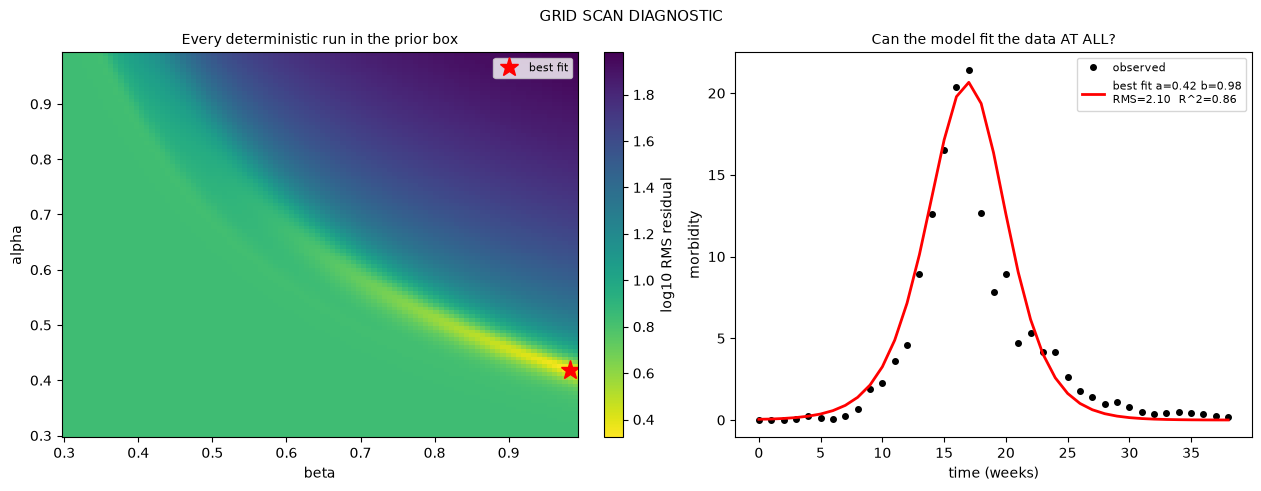

In [26]:
ss_res = float(np.sum((best_curve - Y_OBS) ** 2))
ss_tot = float(np.sum((Y_OBS - Y_OBS.mean()) ** 2))
best_r2 = 1.0 - ss_res / ss_tot
good = RMS < 2.0 * best_rms
frac_good = good.sum() / np.isfinite(RMS).sum()

print("grid: %d x %d = %d runs" % (NA, NB, NA * NB))
print("BEST fit: alpha=%.3f beta=%.3f  RMS=%.3f  R^2=%.3f" %
      (best_ab[0], best_ab[1], best_rms, best_r2))
print("-> recommended epsilon ~ %.2f" % best_rms)
print("fraction of the (alpha,beta) box with RMS < 2*best: %.4f" % frac_good)
print("   (tiny fraction = needle-in-haystack: samplers WILL struggle, use SMC + that epsilon)")

order = np.argsort(RMS, axis=None)[:10]
print("\ntop-10 grid points:")
for k in order:
    i, j = np.unravel_index(k, RMS.shape)
    print("   alpha=%.3f beta=%.3f  RMS=%.3f  R0-ish(a*b)=%.3f" % (A[i], B[j], RMS[i, j], A[i]*B[j]))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
pc = axes[0].pcolormesh(B, A, np.log10(np.maximum(RMS, 1e-3)), cmap="viridis_r")
axes[0].plot(best_ab[1], best_ab[0], "r*", ms=14, label="best fit")
fig.colorbar(pc, ax=axes[0], label="log10 RMS residual")
axes[0].set_xlabel("beta"); axes[0].set_ylabel("alpha")


axes[0].set_title("Every deterministic run in the prior box", fontsize=10)
axes[0].legend(fontsize=8)

tt = np.arange(T)
axes[1].plot(tt, Y_OBS, "ko", ms=4, label="observed")
axes[1].plot(tt, best_curve, "r-", lw=2,
             label="best fit a=%.2f b=%.2f\nRMS=%.2f  R^2=%.2f" % (*best_ab, best_rms, best_r2))
axes[1].set_title("Can the model fit the data AT ALL?", fontsize=10)
axes[1].set_xlabel("time (weeks)"); axes[1].set_ylabel("morbidity")
axes[1].legend(fontsize=8)
fig.suptitle("GRID SCAN DIAGNOSTIC", fontsize=11)

In [33]:
300/60

5.0

In [ ]:
# alpha*beta
method = 'mcmc'
type = 'total'
eps = 2.1

#ess_bulk (7.0 - 10.0): Из всех ваших тысяч шагов сэмплер выдал информацию, эквивалентную всего 7-10 независимым точкам. Это катастрофически мало для оценки среднего значения.

forecast_duration = 4
predictor.generate_forecasts(method=method,
                             type=type,
                             forecast_duration=forecast_duration,
                             epsilon_start=eps,
                             epsilon_end=eps,
                             epsilon_step=1,
                             n_trials=1,
                             sample=300, # choosing N lines for the final plot?
                             tune=1,#1000
                             draws=2000,#1000
                             chains=4)# 6 from Dinara's ipynb

Failed to reload module 'cutils_ext' from file 'C:\Users\105\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26200-SP0-AMD64_Family_25_Model_117_Stepping_2_AuthenticAMD-3.12.7-64\cutils_ext\__init__.py'
Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


Папка уже существует: report_rscf/2026_09_08\mcmc


Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Failed to reload module 'cutils_ext' from file 'C:\Users\105\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26200-SP0-AMD64_Family_25_Model_117_Stepping_2_AuthenticAMD-3.12.7-64\cutils_ext\__init__.py'
Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "D:\Programs\Anaconda\Lib\importlib\__init__.py", line 130, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\105\GitHub\Influenza_bulletin\.venv\Lib\site-packages\IPython\extensions\autoreload.py", lin

Папка уже существует: report_rscf/2026_09_08\mcmc


Multiprocess sampling (10 chains in 4 jobs)
DEMetropolisZ: [alpha, beta]
Sampling 10 chains for 2_000 tune and 500 draw iterations (20_000 + 5_000 draws total) took 62 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


<xarray.Dataset> Size: 160kB
Dimensions:      (alpha_dim_0: 1, samples: 5000, beta_dim_0: 1)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int32 4B 0
  * samples      (samples) object 40kB MultiIndex
  * draw         (samples) int32 20kB 0 0 0 0 0 0 0 ... 499 499 499 499 499 499
  * chain        (samples) int32 20kB 0 1 2 3 4 5 6 7 8 9 ... 1 2 3 4 5 6 7 8 9
  * beta_dim_0   (beta_dim_0) int32 4B 0
Data variables:
    alpha        (alpha_dim_0, samples) float64 40kB 0.4149 0.4122 ... 0.4122
    beta         (beta_dim_0, samples) float64 40kB 0.9934 1.0 ... 1.0 1.0
Attributes:
    created_at:                 2026-09-08T15:50:53.334472+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.25.1
    sampling_time:              62.30962657928467
    tuning_steps:               2000
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  0.412  0.001   0.412    0.414      0.000    0.000      18.0   
beta[0]

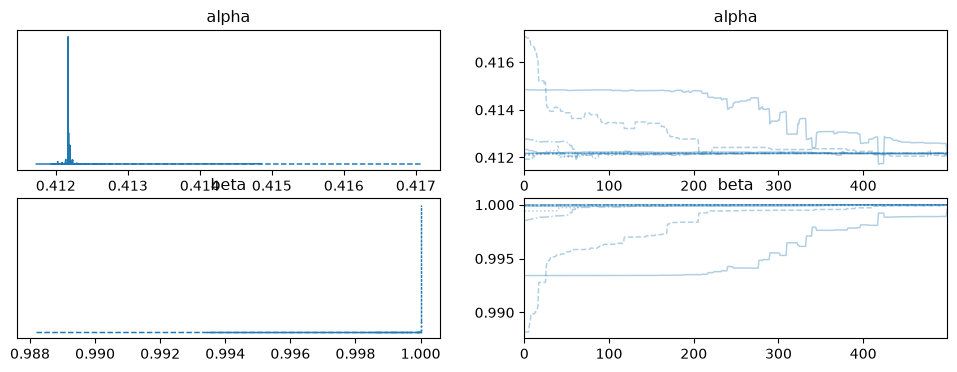

<Figure size 1200x440 with 0 Axes>

<Figure size 1200x440 with 0 Axes>

In [23]:
method = 'mcmc'
type = 'total'
eps = 10

forecast_duration = 4
predictor.generate_forecasts(method=method,
                             type=type,
                             forecast_duration=forecast_duration,
                             epsilon_start=eps,
                             epsilon_end=eps,
                             epsilon_step=1,
                             n_trials=1,
                             sample=600, # choosing N lines for the final plot?
                             tune=2000,#1000
                             draws=500,#1000
                             chains=10)# 6 from Dinara's ipynb

In [ ]:
city = 'russia'
save_path_folder='report_rscf/'
epid_data = InfluenzaData(city, begin_year=2025, begin_week=40, end_year=2025, end_week=49)

predictor = PredictionGenerator(epid_data=epid_data,
                                city=city,
                                save_path=save_path_folder)

In [7]:
epid_data.cases_df.iloc[-1]

datetime                  2025-11-24 00:00:00
region_name                                РФ
district_name                              РФ
sars_total_cases                       432561
sars_cases_age_group_0                  41265
sars_cases_age_group_1                  71891
sars_cases_age_group_2                 118355
sars_cases_age_group_4                 182567
sars_cases_age_group_5                  18483
total_population                     55014040
population_age_group_0                1493462
population_age_group_1                2332343
population_age_group_2                5246924
population_age_group_4               36568656
population_age_group_5                9372655
sars_cases_age_group_3                 201050
population_age_group_3               45941311
rel_strain_0                         0.019813
real_cases_strain_0                    8570.0
rel_strain_1                         0.007655
real_cases_strain_1                    3311.0
rel_strain_2                      

In [3]:
method = 'annealing'
type = 'total'
forecast_duration = 10
predictor.generate_forecasts(method=method,
                             type=type,
                             forecast_duration=forecast_duration,
                             epsilon_start=10,
                             epsilon_end=10,
                             epsilon_step=100,
                             n_trials=1)

Создана папка: ./dinara/report_rscf/2025_12_03_12_57_26\annealing
[[   280.74507912    480.85375592    939.19407791   1842.11127158
    3608.70198117   7049.0594873   13691.49766142  26302.18169702
   49471.14053104  89421.20144053 150408.49847507 224019.97069291
  277658.58658449 271893.19496146 208303.49827117 130171.06782997
   70908.84494993  35693.89309126  17245.02489607]]
[  707.   463.  1307.  3795. 10390. 12575. 19803. 25022. 47876.]
[0.12851265 0.08416033 0.23757572 0.68982391 1.8886088  2.28578014
 3.59962657 4.54829349 8.70250576]


<Figure size 1200x440 with 0 Axes>